# **AASIST: Anti-Spoofing — LA vs PA Cross-Domain Evaluation**

> Trains two AASIST models — one on **Logical Access (LA)** and one on **Physical Access (PA)** — then evaluates each in-domain and cross-domain.

## **1. Environment Setup**

In [29]:
# SKIP THIS CELL — packages already installed in kernel environment (.venv-2)
# If you need to reinstall, uncomment the line below and run:
# !.venv-2/bin/pip install --index-url https://download.pytorch.org/whl/cu124 torch torchaudio librosa numpy pandas scipy scikit-learn matplotlib seaborn plotly kaleido soundfile tqdm prettytable rich thop -q

In [1]:
import os, sys, time, json, random, warnings, math, subprocess
from pathlib import Path
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd
import scipy.signal as signal
import soundfile as sf
import librosa
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm as scipy_norm
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix,
    precision_recall_fscore_support, accuracy_score,
)
from sklearn.model_selection import GroupShuffleSplit
from prettytable import PrettyTable
from rich.console import Console

plt.style.use("seaborn-v0_8-whitegrid")
matplotlib.rcParams.update({
    "figure.dpi": 120, "axes.titlesize": 13,
    "axes.labelsize": 11, "legend.fontsize": 9,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
})
warnings.filterwarnings("ignore")
console = Console()

print("✓ All imports loaded successfully.")

/DATA/llop/.venv-2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ All imports loaded successfully.


## **2. Configuration**

## **1b. GPU Validation** (Run this before any training)

In [2]:
# Device selection & validation
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  ✓ GPU  : {torch.cuda.get_device_name(0)}")
    print(f"  ✓ VRAM : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    print("  ⚠ Warning: CUDA not available. Notebook will run on CPU (very slow).")
    print("  → To use GPU, restart kernel with CUDA-enabled PyTorch in .venv-2 environment.")


Device : cuda
  ✓ GPU  : NVIDIA RTX A5000
  ✓ VRAM : 25.3 GB


In [3]:
@dataclass
class Config:
    # Paths
    la_data_root : str = "/DATA/llop/LA"
    pa_data_root : str = "/DATA/llop/PA"
    model_dir    : str = "models"
    log_dir      : str = "logs"
    plot_dir     : str = "plots"
    results_dir  : str = "results"
    cache_dir    : str = "data/precomputed_tensors"

    # Audio
    sample_rate  : int   = 16000
    n_samples    : int   = 64600
    pre_emphasis : float = 0.97

    # Training
    batch_size              : int   = 64
    num_epochs              : int   = 20
    lr                      : float = 1e-4
    weight_decay            : float = 1e-4
    lr_min                  : float = 1e-6
    scheduler               : str   = "cosine"
    step_size               : int   = 10
    gamma                   : float = 0.5
    early_stopping_patience : int   = 6
    grad_clip               : float = 1.0
    num_workers             : int   = 4

    # Augmentation
    augment         : bool      = True
    aug_prob        : float     = 0.5
    aug_noise_types : List[str] = field(default_factory=lambda:
                                        ["awgn", "babble", "pink", "brown"])
    aug_snr_low     : float     = 0.0
    aug_snr_high    : float     = 30.0

    # AASIST model
    sinc_kernel  : int  = 1024
    nb_samp      : int  = 64600
    filts        : list = field(default_factory=lambda:
                                [70, [70,32], [32,32], [32,64], [64,64]])
    nb_fc_node   : int  = 64
    gat_dims     : list = field(default_factory=lambda: [64, 32])
    temperatures : list = field(default_factory=lambda: [2.0, 2.0, 100.0, 100.0])

    # Splits
    train_ratio : float = 0.70
    val_ratio   : float = 0.15
    test_ratio  : float = 0.15

    # Misc
    seed      : int  = 42
    label_map : dict = field(default_factory=lambda: {"bonafide": 0, "spoof": 1})

CFG = Config()
for d in [CFG.model_dir, CFG.log_dir, CFG.plot_dir, CFG.results_dir, CFG.cache_dir]:
    Path(d).mkdir(parents=True, exist_ok=True)
print("Configuration loaded.")
print(f"LA root: {CFG.la_data_root}")
print(f"PA root: {CFG.pa_data_root}")

Configuration loaded.
LA root: /DATA/llop/LA
PA root: /DATA/llop/PA


## **3. Reproducibility**

In [4]:
def set_seed(seed: int = 42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    print(f"All seeds fixed to {seed}")

set_seed(CFG.seed)


All seeds fixed to 42


## **4. Data Loading**

Both LA and PA are loaded using the same `parse_protocol` helper — which mirrors the LA loading already in the original notebook — applied to each condition's folder.

In [5]:
def parse_protocol(proto_path: Path, audio_dir: Path,
                   split_name: str, condition: str) -> pd.DataFrame:
    """Parse an ASVspoof 2019 protocol .txt file into a tidy DataFrame."""
    rows = []
    with open(proto_path) as fh:
        for line in fh:
            parts = line.strip().split()
            spk_id, utt_id, atk_type, label_str = (
                parts[0], parts[1], parts[3], parts[4])
            rows.append({
                "speaker_id"  : spk_id,
                "utterance_id": utt_id,
                "attack_type" : atk_type,
                "label_str"   : label_str,
                "label"       : CFG.label_map[label_str],
                "audio_path"  : str(audio_dir / f"{utt_id}.flac"),
                "partition"   : split_name,
                "condition"   : condition,
            })
    return pd.DataFrame(rows)


### **4a. LA — Logical Access**

In [ ]:
LA_ROOT = Path(CFG.la_data_root)
print("Detecting LA folder structure...")

try:
    la_train_proto = next(LA_ROOT.rglob("ASVspoof2019.LA.cm.train.trn.txt"))
    la_dev_proto   = next(LA_ROOT.rglob("ASVspoof2019.LA.cm.dev.trl.txt"))
except StopIteration:
    raise FileNotFoundError("LA protocol .txt files not found — check la_data_root.")

try:
    la_train_audio = next(p for p in LA_ROOT.rglob("flac") if "train" in str(p).lower())
    la_dev_audio   = next(p for p in LA_ROOT.rglob("flac") if "dev"   in str(p).lower())
except StopIteration:
    la_train_audio = next(LA_ROOT.rglob("ASVspoof2019_LA_train")) / "flac"
    la_dev_audio   = next(LA_ROOT.rglob("ASVspoof2019_LA_dev"))   / "flac"

print(f"  Train protocol : {la_train_proto}")
print(f"  Train audio    : {la_train_audio}")
                                                                                                                                                                                
df_la_train = parse_protocol(la_train_proto, la_train_audio, "train", "LA")
df_la_dev   = parse_protocol(la_dev_proto,   la_dev_audio,   "dev",   "LA")
df_la       = pd.concat([df_la_train, df_la_dev], ignore_index=True)

print(f"\n  LA train : {len(df_la_train):,}  |  LA dev : {len(df_la_dev):,}  |  Total : {len(df_la):,}")
print(f"  Bonafide / Spoof : {(df_la.label==0).sum():,} / {(df_la.label==1).sum():,}")


Detecting LA folder structure...
  Train protocol : /DATA/llop/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt
  Train audio    : /DATA/llop/LA/LA/ASVspoof2019_LA_train/flac

  LA train : 25,380  |  LA dev : 24,844  |  Total : 50,224
  Bonafide / Spoof : 5,128 / 45,096


### **4b. PA — Physical Access**

In [7]:
PA_ROOT = Path(CFG.pa_data_root)
print("Detecting PA folder structure...")

try:
    pa_train_proto = next(PA_ROOT.rglob("ASVspoof2019.PA.cm.train.trn.txt"))
    pa_dev_proto   = next(PA_ROOT.rglob("ASVspoof2019.PA.cm.dev.trl.txt"))
except StopIteration:
    raise FileNotFoundError("PA protocol .txt files not found — check pa_data_root.")

try:
    pa_train_audio = next(p for p in PA_ROOT.rglob("flac") if "train" in str(p).lower())
    pa_dev_audio   = next(p for p in PA_ROOT.rglob("flac") if "dev"   in str(p).lower())
except StopIteration:
    pa_train_audio = next(PA_ROOT.rglob("ASVspoof2019_PA_train")) / "flac"
    pa_dev_audio   = next(PA_ROOT.rglob("ASVspoof2019_PA_dev"))   / "flac"

print(f"  Train protocol : {pa_train_proto}")
print(f"  Train audio    : {pa_train_audio}")

df_pa_train = parse_protocol(pa_train_proto, pa_train_audio, "train", "PA")
df_pa_dev   = parse_protocol(pa_dev_proto,   pa_dev_audio,   "dev",   "PA")
df_pa       = pd.concat([df_pa_train, df_pa_dev], ignore_index=True)

print(f"\n  PA train : {len(df_pa_train):,}  |  PA dev : {len(df_pa_dev):,}  |  Total : {len(df_pa):,}")
print(f"  Bonafide / Spoof : {(df_pa.label==0).sum():,} / {(df_pa.label==1).sum():,}")


Detecting PA folder structure...
  Train protocol : /DATA/llop/PA/PA/ASVspoof2019_PA_cm_protocols/ASVspoof2019.PA.cm.train.trn.txt
  Train audio    : /DATA/llop/PA/PA/ASVspoof2019_PA_train/flac

  PA train : 54,000  |  PA dev : 29,700  |  Total : 83,700
  Bonafide / Spoof : 10,800 / 72,900


### **4c. Dataset Overview Visualisation**

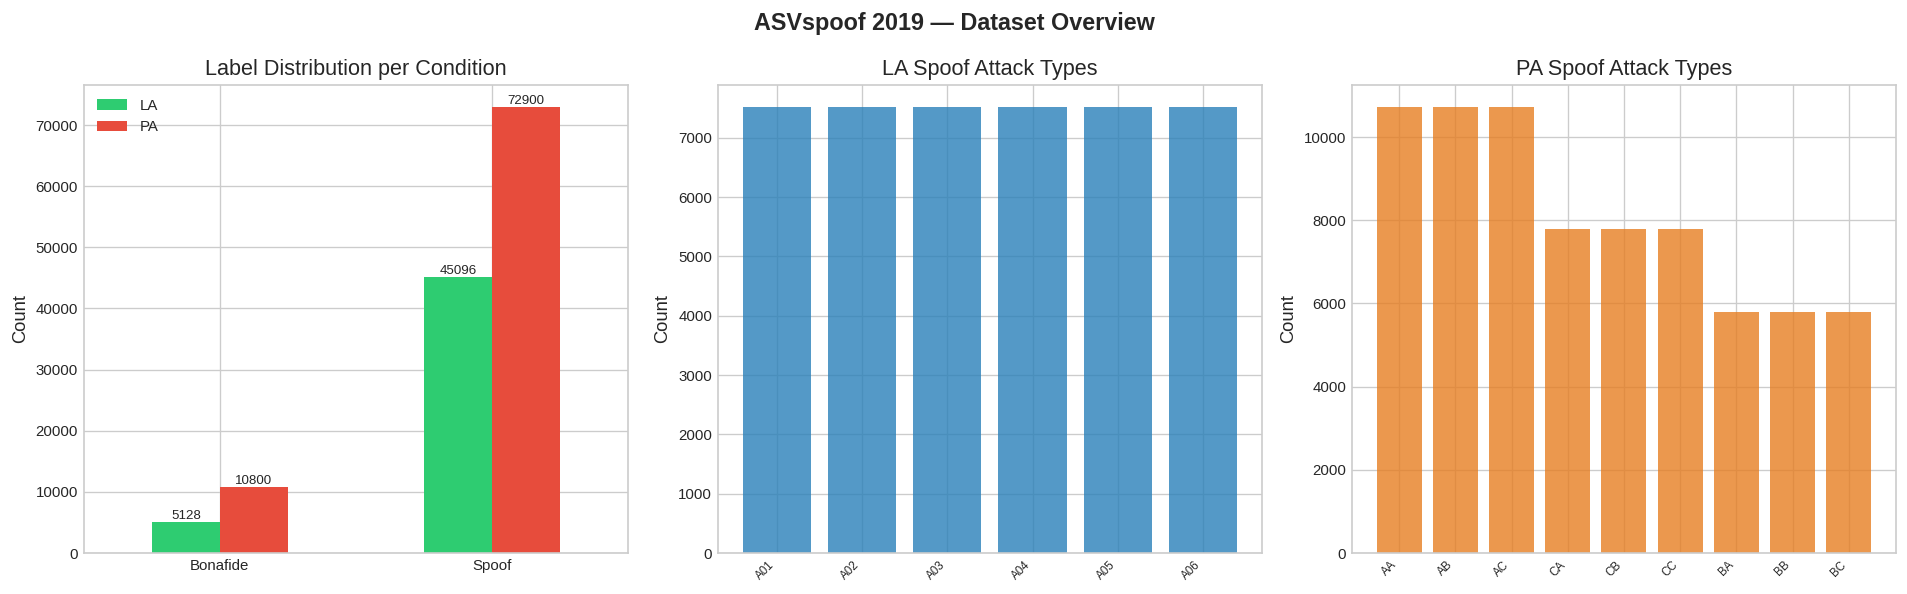

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Label counts
summary = pd.DataFrame({
    "LA": [df_la["label_str"].value_counts().get("bonafide", 0),
            df_la["label_str"].value_counts().get("spoof",    0)],
    "PA": [df_pa["label_str"].value_counts().get("bonafide", 0),
            df_pa["label_str"].value_counts().get("spoof",    0)],
}, index=["Bonafide", "Spoof"])
summary.plot(kind="bar", ax=axes[0], color=["#2ecc71","#e74c3c"], rot=0)
axes[0].set_title("Label Distribution per Condition")
axes[0].set_ylabel("Count")
for c in axes[0].containers:
    axes[0].bar_label(c, fmt="%d", label_type="edge", fontsize=8)

# LA attack types
la_atk = df_la[df_la.label==1]["attack_type"].value_counts()
axes[1].bar(range(len(la_atk)), la_atk.values, color="#2980b9", alpha=0.8)
axes[1].set_xticks(range(len(la_atk)))
axes[1].set_xticklabels(la_atk.index, rotation=45, ha="right", fontsize=7)
axes[1].set_title("LA Spoof Attack Types")
axes[1].set_ylabel("Count")

# PA attack types
pa_atk = df_pa[df_pa.label==1]["attack_type"].value_counts()
axes[2].bar(range(len(pa_atk)), pa_atk.values, color="#e67e22", alpha=0.8)
axes[2].set_xticks(range(len(pa_atk)))
axes[2].set_xticklabels(pa_atk.index, rotation=45, ha="right", fontsize=7)
axes[2].set_title("PA Spoof Attack Types")
axes[2].set_ylabel("Count")

plt.suptitle("ASVspoof 2019 — Dataset Overview", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CFG.plot_dir}/dataset_overview.png", dpi=150, bbox_inches="tight")
plt.show()


## **5. Dataset Splitting**

Speaker-disjoint 70 / 15 / 15 splits using `GroupShuffleSplit` so no speaker appears in both train and test.

In [ ]:
def grouped_split(df: pd.DataFrame,
                  train_r: float, val_r: float, seed: int) -> pd.DataFrame:
    """Assign speaker-disjoint train/val/test labels to a DataFrame."""
    df = df.copy()
    df["split"] = "test"

    gss1 = GroupShuffleSplit(n_splits=1, train_size=train_r, random_state=seed)
    train_idx, temp_idx = next(gss1.split(df, groups=df.speaker_id))
    df.iloc[train_idx, df.columns.get_loc("split")] = "train"

    temp_df  = df.iloc[temp_idx].reset_index(drop=True)
    val_frac = val_r / (1 - train_r)
    gss2 = GroupShuffleSplit(n_splits=1, train_size=val_frac, random_state=seed)
    val_rel, _ = next(gss2.split(temp_df, groups=temp_df.speaker_id))
    df.iloc[temp_idx[val_rel], df.columns.get_loc("split")] = "val"

    return df

set_LA = grouped_split(df_la, CFG.train_ratio, CFG.val_ratio, CFG.seed)
set_PA = grouped_split(df_pa, CFG.train_ratio, CFG.val_ratio, CFG.seed)

for name, s in [("LA", set_LA), ("PA", set_PA)]:
    counts = s.groupby("split").size()
    print(f"{name} — train: {counts.get('train',0):,}  "
          f"val: {counts.get('val',0):,}  test: {counts.get('test',0):,}")


LA — train: 33,812  val: 5,163  test: 11,249
PA — train: 56,160  val: 11,070  test: 16,470


## **6. Pre-processing Pipeline**

Pre-emphasis → energy VAD → RMS normalisation → deterministic/random pad-or-crop.

In [10]:
def _decode_with_ffmpeg(path: str, sr: int) -> np.ndarray:
    cmd = [
        "ffmpeg",
        "-nostdin",
        "-hide_banner",
        "-loglevel", "error",
        "-i", path,
        "-f", "f32le",
        "-ac", "1",
        "-ar", str(sr),
        "pipe:1",
    ]
    raw = subprocess.check_output(cmd, stderr=subprocess.STDOUT)
    return np.frombuffer(raw, dtype=np.float32)


def load_waveform(path: str, sr: int = 16000) -> Tuple[np.ndarray, int]:
    try:
        wave, orig_sr = sf.read(path, always_2d=False)
        if orig_sr != sr:
            wave = librosa.resample(wave.astype(np.float32), orig_sr=orig_sr, target_sr=sr)
        return wave.astype(np.float32), sr
    except Exception:
        try:
            wave, _ = librosa.load(path, sr=sr, mono=True)
            return wave.astype(np.float32), sr
        except Exception:
            wave = _decode_with_ffmpeg(path, sr)
            return wave.astype(np.float32), sr

def pre_emphasis_filter(wave: np.ndarray, coef: float = 0.97) -> np.ndarray:
    return np.append(wave[0], wave[1:] - coef * wave[:-1])

def energy_vad(wave: np.ndarray, sr: int = 16000,
               frame_ms: int = 25, hop_ms: int = 10,
               threshold_db: float = -40.0) -> np.ndarray:
    frame_len = int(sr * frame_ms / 1000)
    hop_len   = int(sr * hop_ms   / 1000)
    frames    = librosa.util.frame(wave, frame_length=frame_len, hop_length=hop_len)
    energy    = 20 * np.log10(np.sqrt(np.mean(frames**2, axis=0)) + 1e-9)
    voiced    = energy > energy.max() + threshold_db
    if not voiced.any(): return wave
    first = voiced.argmax() * hop_len
    last  = (len(voiced) - voiced[::-1].argmax()) * hop_len
    return wave[first:last]

def rms_normalise(wave: np.ndarray, target_db: float = -23.0) -> np.ndarray:
    rms = np.sqrt(np.mean(wave**2) + 1e-9)
    return wave * (10 ** (target_db / 20) / rms)

def pad_or_crop(wave: np.ndarray,
                n_samples: int = 64600,
                training: bool = True) -> np.ndarray:
    if len(wave) >= n_samples:
        start = (random.randint(0, len(wave) - n_samples)
                 if training else (len(wave) - n_samples) // 2)
        return wave[start : start + n_samples]
    return np.tile(wave, n_samples // len(wave) + 1)[:n_samples]


## **7. Offline Cache Building**

Processes every utterance once and saves as `.pt`. Eliminates CPU bottleneck during training (~20 min on CPU, run once).

In [40]:
CACHE_DIR = Path("data/precomputed_tensors")


def build_offline_cache(df: pd.DataFrame, desc: str):
    bad_files = []
    created = 0
    skipped_existing = 0

    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Caching {desc}"):
        out_path = CACHE_DIR / f"{row.utterance_id}.pt"
        if out_path.exists():
            skipped_existing += 1
            continue

        try:
            wave, _ = load_waveform(row.audio_path)
            wave = rms_normalise(energy_vad(pre_emphasis_filter(wave)))
            torch.save(torch.from_numpy(wave).float(), out_path)
            created += 1
        except Exception as e:
            bad_files.append((row.audio_path, str(e)))

    print(f"{desc}: created={created}, already_cached={skipped_existing}, failed={len(bad_files)}")
    if bad_files:
        print("First 10 failed files:")
        for p, err in bad_files[:10]:
            print(f"  - {p} -> {err}")


# Set these flags to control which cache to build.
RUN_LA_CACHE = False
RUN_PA_CACHE = True

print("Building offline tensor cache...")
if RUN_LA_CACHE:
    build_offline_cache(set_LA, "LA - Logical Access")
if RUN_PA_CACHE:
    build_offline_cache(set_PA, "PA - Physical Access")
print("Cache step finished.")

Building offline tensor cache...


Caching PA - Physical Access: 100%|██████████| 83700/83700 [00:05<00:00, 16432.00it/s]

PA - Physical Access: created=0, already_cached=83700, failed=0
Cache step finished.


## **8. Data Augmentation**

In [11]:
class NoiseAugmentor:
    def __init__(self,
                 noise_types: List[str] = CFG.aug_noise_types,
                 snr_low: float = CFG.aug_snr_low,
                 snr_high: float = CFG.aug_snr_high,
                 prob: float = CFG.aug_prob):
        self.noise_types          = noise_types
        self.snr_low, self.snr_high = snr_low, snr_high
        self.prob                 = prob

    @staticmethod
    def _awgn(n): return np.random.randn(n).astype(np.float32)

    @staticmethod
    def _pink(n):
        sr    = max(n // 16, 1)
        white = np.random.randn(n + sr).astype(np.float32)
        b = [0.049922035, -0.095993537,  0.050612699, -0.004408786]
        a = [1.0,         -2.494956002,  2.017265875, -0.522189400]
        return signal.lfilter(b, a, white)[sr:sr+n]

    @staticmethod
    def _brown(n):
        b = np.cumsum(np.random.randn(n).astype(np.float32))
        return b - b.mean()

    def _babble(self, n, n_spk=6):
        b = np.zeros(n, dtype=np.float32)
        for _ in range(n_spk):
            b += np.roll(np.random.randn(n).astype(np.float32),
                          np.random.randint(0, n))
        return b

    def add_noise(self, wave):
        ntype = random.choice(self.noise_types)
        snr   = np.random.uniform(self.snr_low, self.snr_high)
        noise = {"awgn":self._awgn,"pink":self._pink,
                 "brown":self._brown,"babble":self._babble}[ntype](len(wave))
        scale = (np.sqrt(np.mean(wave**2)+1e-9)
                 / (np.sqrt(np.mean(noise**2)+1e-9) * 10**(snr/20)))
        return (wave + scale * noise).astype(np.float32)

    def __call__(self, wave):
        return self.add_noise(wave) if random.random() < self.prob else wave

AUGMENTOR = NoiseAugmentor()
print("Augmentor ready.")


Augmentor ready.


## **9. PyTorch Dataset & DataLoaders**

In [ ]:
# Ensure cache path exists in current kernel state, even if cache-building cell was not rerun.
CACHE_DIR = Path(getattr(CFG, "cache_dir", "data/precomputed_tensors"))


class ASVDataset(Dataset):
    def __init__(self, df: pd.DataFrame,
                 split: str = "train",
                 augment: bool = True,
                 n_samples: int = CFG.n_samples):
        self.df = df[df.split == split].reset_index(drop=True)
        self.training = augment and (split == "train")
        self.n_samples = n_samples

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = CACHE_DIR / f"{row.utterance_id}.pt"

        if not path.exists():
            raise FileNotFoundError(f"Missing cached tensor: {path}")

        raw = torch.load(path, weights_only=True)
        if isinstance(raw, torch.Tensor):
            wave = raw.detach().cpu().numpy()
        elif isinstance(raw, np.ndarray):
            wave = raw
        else:
            wave = np.asarray(raw)

        wave = wave.astype(np.float32, copy=False)

        if self.training:
            wave = AUGMENTOR(wave)

        wave = pad_or_crop(wave, self.n_samples, training=self.training)
        if isinstance(wave, torch.Tensor):
            wave = wave.detach().cpu().numpy()
        wave = np.asarray(wave, dtype=np.float32)

        return (
            torch.from_numpy(wave).unsqueeze(0),
            torch.tensor(row.label, dtype=torch.long),
            row.utterance_id,
        )


def _build_balanced_train_sampler(df_use: pd.DataFrame) -> torch.utils.data.WeightedRandomSampler:
    train_df = df_use[df_use.split == "train"].reset_index(drop=True)
    label_counts = train_df["label"].value_counts().sort_index()
    inv_freq = {int(lbl): 1.0 / float(cnt) for lbl, cnt in label_counts.items()}
    sample_weights = train_df["label"].map(inv_freq).astype(np.float64).values

    return torch.utils.data.WeightedRandomSampler(
        weights=torch.from_numpy(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
    )


def make_loaders(df: pd.DataFrame,
                 batch_size: int = CFG.batch_size,
                 augment: bool = CFG.augment,
                 num_workers: int = 0) -> Dict[str, DataLoader]:
    # Strictly disjoint training: no cross-domain concatenation, use only provided df.
    df_use = df.copy()

    train_df = df_use[df_use.split == "train"]
    train_counts = train_df["label"].value_counts().sort_index().to_dict()
    print(f"Train class counts (raw): {train_counts}")

    train_sampler = _build_balanced_train_sampler(df_use)

    return {
        "train": DataLoader(
            ASVDataset(df_use, split="train", augment=augment),
            batch_size=batch_size,
            shuffle=False,
            sampler=train_sampler,   # class balancing kept
            num_workers=num_workers,
            pin_memory=(DEVICE.type == "cuda"),
            drop_last=True,
        ),
        "val": DataLoader(
            ASVDataset(df_use, split="val", augment=False),
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers,
            pin_memory=(DEVICE.type == "cuda"),
            drop_last=False,
        ),
        "test": DataLoader(
            ASVDataset(df_use, split="test", augment=False),
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers,
            pin_memory=(DEVICE.type == "cuda"),
            drop_last=False,
        ),
    }


print("Building LA DataLoaders...")
loaders_LA = make_loaders(set_LA)

print("Building PA DataLoaders...")
loaders_PA = make_loaders(set_PA)

print("DataLoaders ready (disjoint, balanced).")

Building LA DataLoaders...
Train class counts (raw): {0: 5809, 1: 44851}
Building PA DataLoaders...
Train class counts (raw): {0: 8597, 1: 57707}
DataLoaders ready.


## **10. AASIST Model Architecture**

Full AASIST: **SincConv** learnable filterbank → Residual encoder → **Heterogeneous Stacked Graph Attention Layer (HSGAL)** → 2-class head.

In [13]:
class SincConv(nn.Module):
    @staticmethod
    def to_mel(hz):  return 2595 * math.log10(1 + hz / 700)
    @staticmethod
    def to_hz(mel):  return 700 * (10 ** (mel / 2595) - 1)

    def __init__(self, out_channels, kernel_size, sr=16000,
                 min_low_hz=50, min_band_hz=50):
        super().__init__()
        if kernel_size % 2 == 0: kernel_size += 1
        self.out_channels = out_channels
        self.kernel_size  = kernel_size
        self.sample_rate  = sr
        self.min_low_hz   = min_low_hz
        self.min_band_hz  = min_band_hz

        low_hz = 30.0
        high_hz = sr / 2 - (min_low_hz + min_band_hz)
        mel = np.linspace(self.to_mel(low_hz), self.to_mel(high_hz), out_channels + 1)
        hz  = self.to_hz(mel)
        self.low_hz_  = nn.Parameter(torch.Tensor(hz[:-1]).view(-1, 1))
        self.band_hz_ = nn.Parameter(torch.Tensor(np.diff(hz)).view(-1, 1))

        n_lin = torch.linspace(0, kernel_size / 2 - 1, kernel_size // 2)
        self.register_buffer("window_",
            0.54 - 0.46 * torch.cos(2 * math.pi * n_lin / kernel_size))
        n = (kernel_size - 1) / 2.0
        self.register_buffer("n_",
            2 * math.pi * torch.arange(-n, 0).view(1, -1) / sr)

    def forward(self, x):
        low  = self.min_low_hz + torch.abs(self.low_hz_)
        high = torch.clamp(low + self.min_band_hz + torch.abs(self.band_hz_),
                           self.min_low_hz, self.sample_rate / 2)
        band = (high - low)[:, 0]
        f_l  = torch.matmul(low,  self.n_)
        f_h  = torch.matmul(high, self.n_)
        bp_l = ((torch.sin(f_h) - torch.sin(f_l)) / (self.n_ / 2)) * self.window_
        bp   = torch.cat([bp_l, 2 * band.view(-1,1), torch.flip(bp_l, [1])], 1)
        bp   = bp / (2 * band[:, None])
        return F.conv1d(x, bp.view(self.out_channels, 1, self.kernel_size),
                        padding=self.kernel_size // 2)


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, first=False):
        super().__init__()
        self.first = first
        self.lrelu = nn.LeakyReLU(0.3)
        if not first: self.bn1 = nn.BatchNorm1d(in_ch)
        self.conv1 = nn.Conv1d(in_ch,  out_ch, 3, padding=1)
        self.bn2   = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, 3, padding=1)
        self.skip  = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        identity = self.skip(x)
        out = x if self.first else self.lrelu(self.bn1(x))
        return self.conv2(self.lrelu(self.bn2(self.conv1(out)))) + identity


class GraphAttentionLayer(nn.Module):
    def __init__(self, in_dim, out_dim, K=4):
        super().__init__()
        self.K     = K
        self.proj  = nn.Linear(in_dim, out_dim, bias=False)
        self.attn  = nn.Linear(2 * out_dim, 1, bias=False)
        self.lrelu = nn.LeakyReLU(0.2)

    def forward(self, x):
        B, N, _ = x.shape
        h  = self.proj(x)
        e  = self.lrelu(self.attn(torch.cat([
            h.unsqueeze(2).expand(-1,-1,N,-1),
            h.unsqueeze(1).expand(-1,N,-1,-1)], -1)).squeeze(-1))
        if self.K < N:
            thr = torch.topk(e, min(self.K,N), -1).values[..., -1:]
            e   = e.masked_fill(e < thr, float("-inf"))
        return F.elu(torch.bmm(F.softmax(e, -1), h)), None


class HSGAL(nn.Module):
    def __init__(self, dim_s, dim_t, gat_dims, K=4, temperature=2.0):
        super().__init__()
        self.gat_s = GraphAttentionLayer(dim_s, gat_dims[0], K)
        self.gat_t = GraphAttentionLayer(dim_t, gat_dims[0], K)
        self.cross = nn.Linear(gat_dims[0], gat_dims[1])
        self.temp  = temperature

    def _attend(self, query_src, key_src):
        q = self.cross(query_src.mean(1, keepdim=True))
        k = self.cross(key_src)
        a = F.softmax(torch.bmm(q, k.transpose(1,2)) / self.temp, -1)
        return torch.bmm(a, k).squeeze(1)

    def forward(self, xs, xt):
        hs, _ = self.gat_s(xs)
        ht, _ = self.gat_t(xt)
        return torch.cat([self._attend(hs, ht), self._attend(ht, hs)], 1)


class AASIST(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.sinc  = SincConv(70, cfg.sinc_kernel, sr=cfg.sample_rate)
        self.bn0   = nn.BatchNorm1d(70)
        self.pool0 = nn.MaxPool1d(3)
        self.drop0 = nn.Dropout(0.05)

        self.enc_blocks = nn.ModuleList()
        self.enc_pools  = nn.ModuleList()
        for i, flt in enumerate(cfg.filts[1:]):
            self.enc_blocks.append(ResBlock(flt[0], flt[1], first=(i==0)))
            self.enc_pools.append(nn.MaxPool1d(3))
        self.block_last = ResBlock(64, 64)
        self.bn_last    = nn.BatchNorm1d(64)
        self.drop_last  = nn.Dropout(0.05)

        self.hsgal = HSGAL(64, 64, cfg.gat_dims, K=4, temperature=cfg.temperatures[0])
        self.fc1   = nn.Linear(2 * cfg.gat_dims[1], cfg.nb_fc_node)
        self.bn_fc = nn.BatchNorm1d(cfg.nb_fc_node)
        self.fc2   = nn.Linear(cfg.nb_fc_node, 2)

    def forward(self, x):
        out = F.leaky_relu(self.bn0(torch.abs(self.sinc(x))), 0.3)
        out = self.drop0(self.pool0(out))
        for blk, pool in zip(self.enc_blocks, self.enc_pools):
            out = pool(blk(out))
        out = self.drop_last(F.leaky_relu(self.bn_last(self.block_last(out)), 0.3))
        xs  = out.permute(0, 2, 1)
        h   = F.leaky_relu(self.bn_fc(self.fc1(self.hsgal(xs, xs))), 0.3)
        return self.fc2(h)

print("AASIST model class defined.")


AASIST model class defined.


## **11. Training Utilities**

Weighted CE loss, optimiser/scheduler, EER + ISO metrics, early stopping, and the AMP-accelerated epoch loop.

In [ ]:
def weighted_ce_loss(df: pd.DataFrame) -> nn.CrossEntropyLoss:
    counts  = df[df.split == "train"].label.value_counts().sort_index()
    n_total = counts.sum()
    n_cls   = len(counts)
    weights = torch.tensor(
        [n_total / (n_cls * counts[c]) for c in range(n_cls)],
        dtype=torch.float, device=DEVICE)
    return nn.CrossEntropyLoss(weight=weights)

def build_optimizer_scheduler(model, cfg):
    opt = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    if cfg.scheduler == "cosine":
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg.num_epochs, eta_min=cfg.lr_min)
    elif cfg.scheduler == "step":
        sch = torch.optim.lr_scheduler.StepLR(opt, step_size=cfg.step_size, gamma=cfg.gamma)
    else:
        sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=5, min_lr=cfg.lr_min)
    return opt, sch

def compute_eer(labels, scores):
    fpr, tpr, thr = roc_curve(labels, scores, pos_label=1)
    fnr = 1.0 - tpr
    idx = np.abs(fnr - fpr).argmin()
    return float((fpr[idx]+fnr[idx])/2), float(thr[idx])

def compute_all_metrics(labels, scores, threshold):
    preds = (scores >= threshold).astype(int)
    tn,fp,fn,tp = confusion_matrix(labels, preds, labels=[0,1]).ravel()
    prec,rec,f1,_ = precision_recall_fscore_support(labels, preds, labels=[0,1], zero_division=0)
    fpr_arr, tpr_arr, _ = roc_curve(labels, scores, pos_label=1)
    apcer = fn / (tp+fn+1e-9)
    bpcer = fp / (tn+fp+1e-9)
    return {
        "eer": compute_eer(labels,scores)[0], "threshold": threshold,
        "auc_roc": auc(fpr_arr,tpr_arr), "accuracy": accuracy_score(labels,preds),
        "precision_bonafide":prec[0],"recall_bonafide":rec[0],"f1_bonafide":f1[0],
        "precision_spoof":prec[1],    "recall_spoof":rec[1],  "f1_spoof":f1[1],
        "apcer":apcer,"bpcer":bpcer,"acer":(apcer+bpcer)/2,
        "TN":int(tn),"FP":int(fp),"FN":int(fn),"TP":int(tp),
        "fpr_arr":fpr_arr,"tpr_arr":tpr_arr,
    }

def print_model_summary_table(m_in, m_out, model_name, in_lbl, out_lbl):
    t = PrettyTable()
    t.title = f"  {model_name} — Performance Summary"
    t.field_names = ["Condition","EER (%)","ACER (%)","APCER (%)","BPCER (%)","AUC-ROC","Accuracy"]
    t.align = "r"; t.align["Condition"] = "l"
    for m,lbl in [(m_in,f"In-Domain ({in_lbl})"),(m_out,f"Cross-Domain ({out_lbl})")]:
        t.add_row([lbl,f"{m['eer']*100:.2f}",f"{m['acer']*100:.2f}",
                   f"{m['apcer']*100:.2f}",f"{m['bpcer']*100:.2f}",
                   f"{m['auc_roc']:.4f}",f"{m['accuracy']*100:.2f}%"])
    return t


class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-4, save_path="best.pt"):
        self.patience  = patience
        self.min_delta = min_delta
        self.save_path = save_path
        self.best      = float("inf")
        self.counter   = 0

    def __call__(self, score, model):
        if score < self.best - self.min_delta:
            self.best, self.counter = score, 0
            torch.save(model.state_dict(), self.save_path)
            return False
        self.counter += 1
        return self.counter >= self.patience


def run_epoch(model, loader, criterion, optimizer, device, scaler,
              training=True, grad_clip=CFG.grad_clip):
    model.train(training)
    total_loss = total_correct = total_n = 0
    all_lbl, all_scr = [], []
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for x, y, _ in loader:
            x, y = x.to(device), y.to(device)
            with torch.autocast("cuda", dtype=torch.float16,
                                enabled=(device.type=="cuda")):
                logits = model(x)
                loss   = criterion(logits, y)
            if training:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                scaler.step(optimizer); scaler.update()
            scr = F.softmax(logits, 1)[:,1].detach().cpu().numpy()
            total_loss    += loss.item() * x.size(0)
            total_correct += (logits.argmax(1).cpu() == y.cpu()).sum().item()
            total_n       += x.size(0)
            all_lbl.extend(y.cpu().numpy().tolist())
            all_scr.extend(scr.tolist())
    return (total_loss/(total_n+1e-9), total_correct/(total_n+1e-9),
            np.array(all_lbl), np.array(all_scr))


def train_model(model, loaders, criterion, optimizer, scheduler, cfg, run_name):
    save_path = str(Path(cfg.model_dir)/f"{run_name}_best.pt")
    es        = EarlyStopping(patience=cfg.early_stopping_patience, save_path=save_path)
    scaler    = torch.cuda.amp.GradScaler(enabled=(DEVICE.type=="cuda"))
    history   = {"train_loss":[],"val_loss":[],"train_acc":[],"val_acc":[],"val_eer":[],"lr":[]}
    best_thr  = 0.5

    try:
        for epoch in range(1, cfg.num_epochs + 1):
            tl, ta, _,  _  = run_epoch(model, loaders["train"], criterion, optimizer, DEVICE, scaler, True)
            vl, va, vl_, vs = run_epoch(model, loaders["val"],   criterion, None,      DEVICE, scaler, False)
            eer, thr = compute_eer(vl_, vs)
            best_thr = thr
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau): scheduler.step(eer)
            else: scheduler.step()
            lr = optimizer.param_groups[0]["lr"]
            history["train_loss"].append(tl); history["val_loss"].append(vl)
            history["train_acc"].append(ta);  history["val_acc"].append(va)
            history["val_eer"].append(eer);   history["lr"].append(lr)
            if es(eer, model):
                break
    except KeyboardInterrupt:
        pass

    model.load_state_dict(torch.load(save_path, map_location=DEVICE))
    return model, best_thr, history

Training utilities defined.


## **12. Visualisation Helpers**

In [15]:
PALETTE = {
    "bonafide":"#2ecc71","spoof":"#e74c3c",
    "primary":"#2980b9","secondary":"#8e44ad","neutral":"#95a5a6",
    "LA":"#2980b9","PA":"#e67e22",
}

def plot_training_curves(history, run_name, save_prefix=""):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    axes[0,0].plot(epochs, history["train_loss"], label="Train", color=PALETTE["primary"],   lw=2)
    axes[0,0].plot(epochs, history["val_loss"],   label="Val",   color=PALETTE["secondary"], lw=2, ls="--")
    axes[0,0].set_title("Loss"); axes[0,0].legend()
    axes[0,1].plot(epochs, [a*100 for a in history["train_acc"]], label="Train", color=PALETTE["primary"],   lw=2)
    axes[0,1].plot(epochs, [a*100 for a in history["val_acc"]],   label="Val",   color=PALETTE["secondary"], lw=2, ls="--")
    axes[0,1].set_title("Accuracy (%)"); axes[0,1].legend()
    axes[1,0].plot(epochs, [e*100 for e in history["val_eer"]], color=PALETTE["spoof"], lw=2)
    axes[1,0].set_title("Validation EER (%)")
    axes[1,1].semilogy(epochs, history["lr"], color=PALETTE["neutral"], lw=2)
    axes[1,1].set_title("Learning Rate")
    plt.suptitle(f"Training Curves — {run_name}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    if save_prefix:
        plt.savefig(f"{CFG.plot_dir}/{save_prefix}_curves.png", dpi=150, bbox_inches="tight")
    plt.show()

def plot_score_distribution(labels, scores, threshold, title, save_prefix=""):
    fig, ax = plt.subplots(figsize=(9, 5))
    for lab, name, color in [(0,"Bonafide",PALETTE["bonafide"]),(1,"Spoof",PALETTE["spoof"])]:
        ax.hist(scores[labels==lab], bins=80, density=True,
                alpha=0.55, label=name, color=color, edgecolor="white", lw=0.3)
    ax.axvline(threshold, color="k", ls="--", lw=2, label=f"Threshold={threshold:.3f}")
    ax.set_xlabel("Spoof Score"); ax.set_ylabel("Density")
    ax.set_title(f"Score Distribution — {title}", fontweight="bold"); ax.legend()
    plt.tight_layout()
    if save_prefix:
        plt.savefig(f"{CFG.plot_dir}/{save_prefix}_scores.png", dpi=150, bbox_inches="tight")
    plt.show()

def plot_confusion_matrix(metrics, label, save_prefix=""):
    cm     = np.array([[metrics["TN"],metrics["FP"]],[metrics["FN"],metrics["TP"]]])
    cm_pct = cm.astype(float)/cm.sum()*100
    annot  = np.array([[f"{v}\n({p:.1f}%)" for v,p in zip(rv,rp)]
                        for rv,rp in zip(cm,cm_pct)])
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=annot, fmt="", cmap="Blues",
                xticklabels=["Pred Bonafide","Pred Spoof"],
                yticklabels=["True Bonafide","True Spoof"],
                cbar=False, ax=ax, linewidths=0.5)
    ax.set_title(f"Confusion Matrix — {label}", fontweight="bold")
    plt.tight_layout()
    if save_prefix:
        plt.savefig(f"{CFG.plot_dir}/{save_prefix}_cm.png", dpi=150, bbox_inches="tight")
    plt.show()

def plot_roc_and_det(metrics_dict, run_name, save_prefix=""):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    colors = [PALETTE["primary"], PALETTE["spoof"]]
    eps = 1e-6
    for (lbl, m), color in zip(metrics_dict.items(), colors):
        axes[0].plot(m["fpr_arr"], m["tpr_arr"],
                     label=f"{lbl}  AUC={m['auc_roc']:.4f}", color=color, lw=2)
        axes[0].scatter([m["eer"]], [1-m["eer"]], color=color, s=80, zorder=5)
        fpr_nd = scipy_norm.ppf(np.clip(m["fpr_arr"], eps, 1-eps))
        fnr_nd = scipy_norm.ppf(np.clip(1-m["tpr_arr"], eps, 1-eps))
        valid  = np.isfinite(fpr_nd) & np.isfinite(fnr_nd)
        axes[1].plot(fpr_nd[valid], fnr_nd[valid],
                     label=f"{lbl}  EER={m['eer']*100:.2f}%", color=color, lw=2)
    axes[0].plot([0,1],[0,1],"k--",lw=1)
    axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
    axes[0].set_title(f"ROC Curve — {run_name}", fontweight="bold"); axes[0].legend(loc="lower right")
    ticks = [0.1,1,5,10,20,40]; tloc = scipy_norm.ppf([t/100 for t in ticks])
    for ax in [axes[1]]:
        ax.set_xticks(tloc); ax.set_xticklabels(ticks)
        ax.set_yticks(tloc); ax.set_yticklabels(ticks)
    axes[1].set_xlabel("FPR (%)"); axes[1].set_ylabel("FNR (%)")
    axes[1].set_title(f"DET Curve — {run_name}", fontweight="bold"); axes[1].legend()
    plt.tight_layout()
    if save_prefix:
        plt.savefig(f"{CFG.plot_dir}/{save_prefix}_roc_det.png", dpi=150, bbox_inches="tight")
    plt.show()

print("Visualisation helpers defined.")


Visualisation helpers defined.


## **13. Model A — Trained on LA (Logical Access)**

> Evaluates **in-domain** on the LA test set and **cross-domain** on the PA test set.

### **13a. Train Model A**

In [ ]:
set_seed(CFG.seed)
model_LA     = AASIST(CFG).to(DEVICE)
criterion_LA = weighted_ce_loss(set_LA)
optim_LA, sched_LA = build_optimizer_scheduler(model_LA, CFG)

model_LA, threshold_LA, history_LA = train_model(
    model_LA, loaders_LA, criterion_LA, optim_LA, sched_LA,
    CFG, run_name="ModelA_LA")

### **13b. Evaluate Model A**

In [17]:
eval_scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type=="cuda"))
crit_eval   = nn.CrossEntropyLoss()

if "model_LA" not in globals():
    model_LA = AASIST(CFG).to(DEVICE)
best_ckpt_LA = Path(CFG.model_dir) / "ModelA_LA_best.pt"
if best_ckpt_LA.exists():
    model_LA.load_state_dict(torch.load(best_ckpt_LA, map_location=DEVICE))

if "threshold_LA" not in globals():
    if "loaders_LA" in globals() and "val" in loaders_LA:
        _, _, y_val_LA, s_val_LA = run_epoch(model_LA, loaders_LA["val"], crit_eval, None, DEVICE, eval_scaler, False)
        _, threshold_LA = compute_eer(y_val_LA, s_val_LA)
    else:
        threshold_LA = 0.5

if "history_LA" not in globals():
    history_LA = {"train_loss":[],"val_loss":[],"train_acc":[],"val_acc":[],"val_eer":[],"lr":[]}

print("Evaluating Model A...\n")
_, _, y_LA_in,  s_LA_in  = run_epoch(model_LA, loaders_LA["test"], crit_eval, None, DEVICE, eval_scaler, False)
_, _, y_LA_out, s_LA_out = run_epoch(model_LA, loaders_PA["test"], crit_eval, None, DEVICE, eval_scaler, False)

metrics_LA_in  = compute_all_metrics(y_LA_in,  s_LA_in,  threshold_LA)
metrics_LA_out = compute_all_metrics(y_LA_out, s_LA_out, threshold_LA)

print_model_summary_table(metrics_LA_in, metrics_LA_out,
    "Model A (Trained on LA)", "LA", "PA")


Evaluating Model A...

+-------------------------------------------------------------------------------------+
|                     Model A (Trained on LA) — Performance Summary                   |
+-------------------+---------+----------+-----------+-----------+---------+----------+
| Condition         | EER (%) | ACER (%) | APCER (%) | BPCER (%) | AUC-ROC | Accuracy |
+-------------------+---------+----------+-----------+-----------+---------+----------+
| In-Domain (LA)    |   10.16 |    12.21 |     22.14 |      2.28 |  0.9567 |   79.56% |
| Cross-Domain (PA) |   27.05 |    27.89 |     47.80 |      7.99 |  0.8025 |   56.77% |
+-------------------+---------+----------+-----------+-----------+---------+----------+


### **13c. Visualisations — Model A**

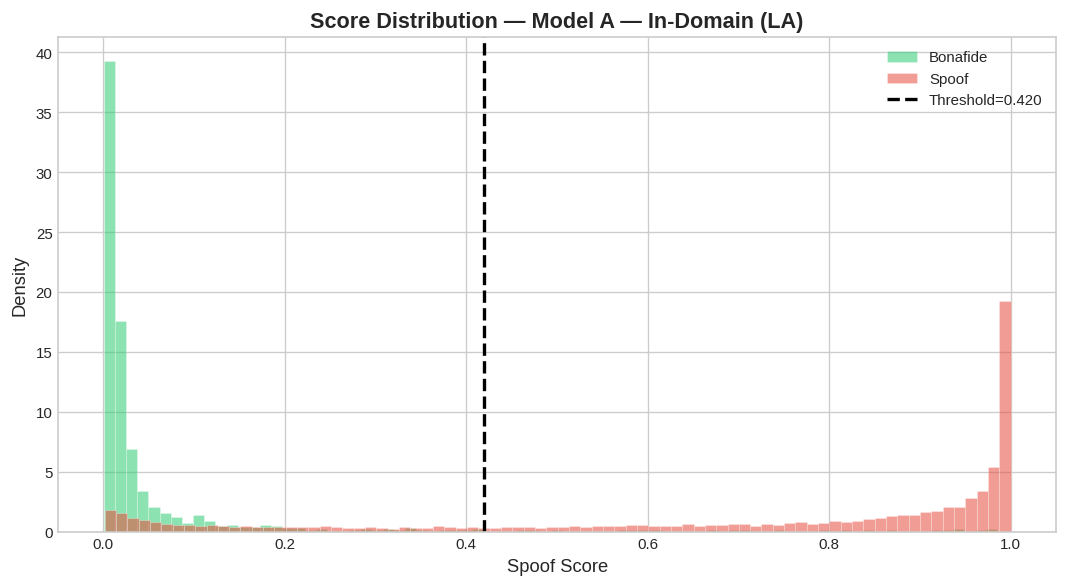

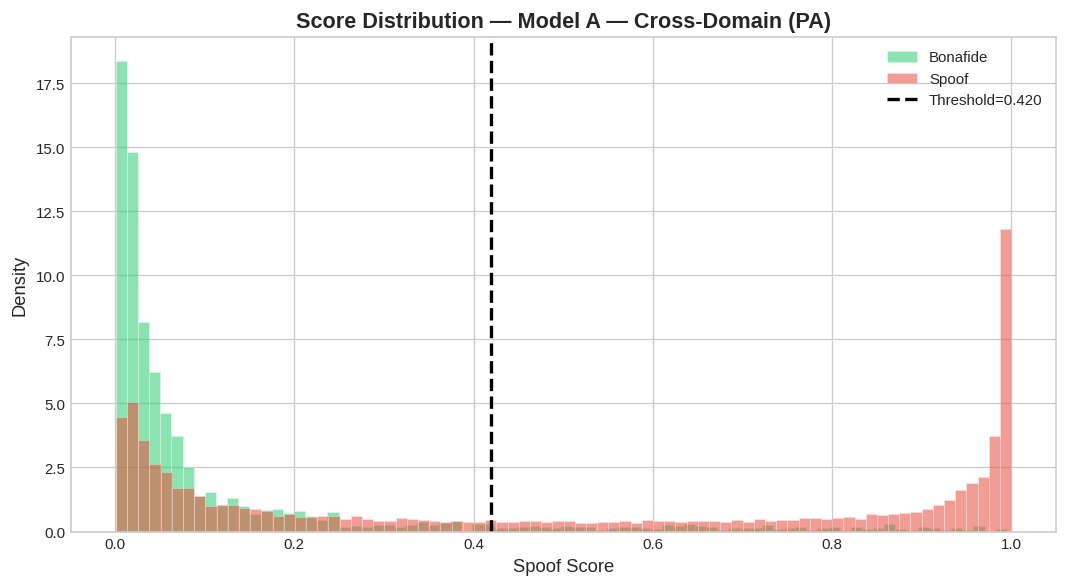

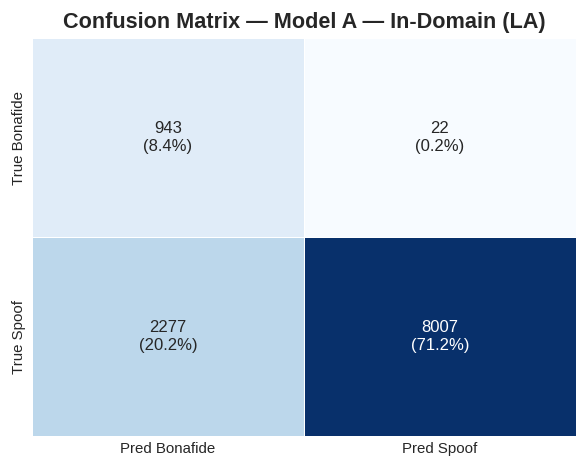

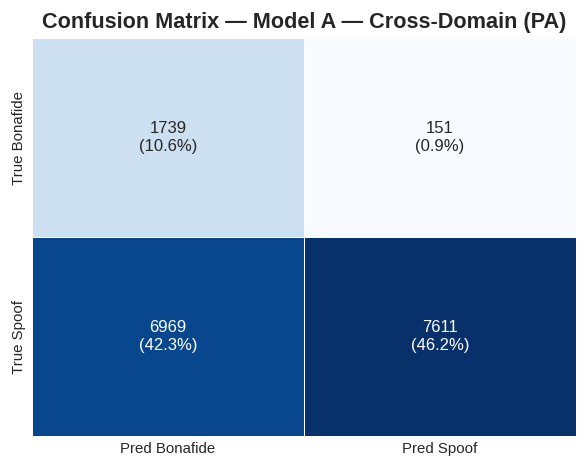

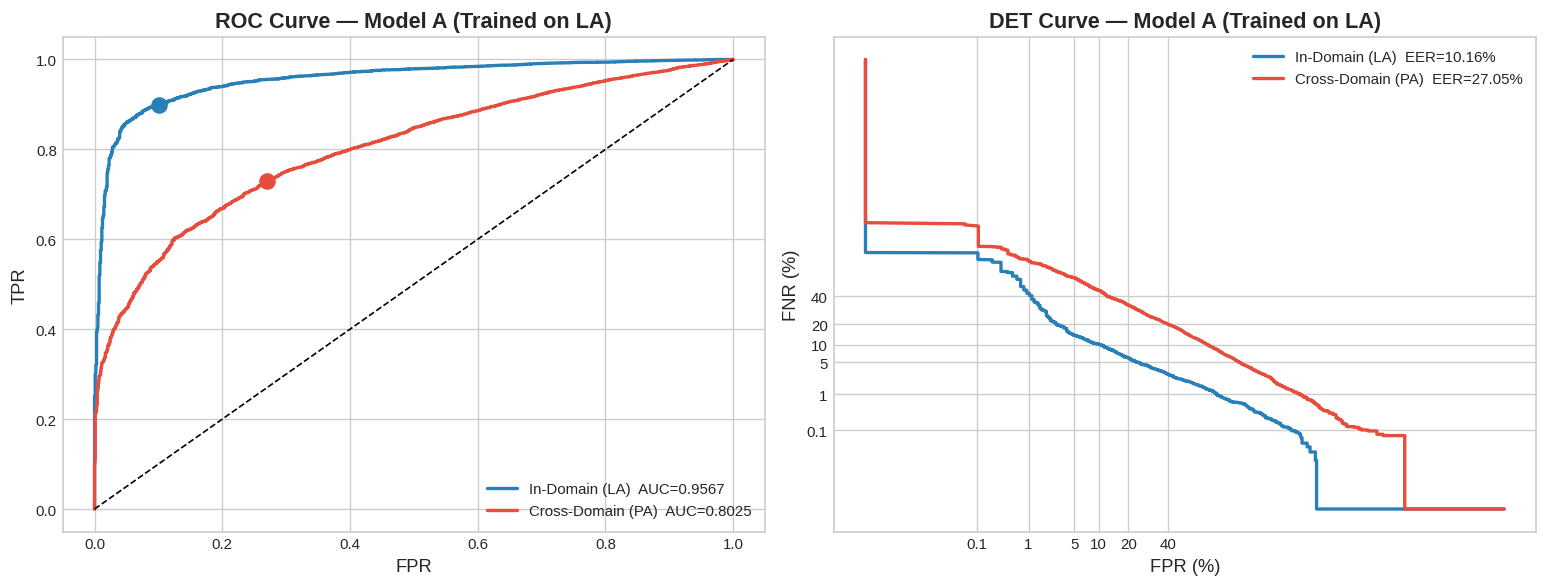

In [18]:
plot_score_distribution(y_LA_in,  s_LA_in,  threshold_LA, "Model A — In-Domain (LA)",    "modelA_in")
plot_score_distribution(y_LA_out, s_LA_out, threshold_LA, "Model A — Cross-Domain (PA)", "modelA_out")
plot_confusion_matrix(metrics_LA_in,  "Model A — In-Domain (LA)",    "modelA_cm_in")
plot_confusion_matrix(metrics_LA_out, "Model A — Cross-Domain (PA)", "modelA_cm_out")
plot_roc_and_det(
    {"In-Domain (LA)": metrics_LA_in, "Cross-Domain (PA)": metrics_LA_out},
    "Model A (Trained on LA)", "modelA")

## **14. Model B — Trained on PA (Physical Access)**

> Evaluates **in-domain** on the PA test set and **cross-domain** on the LA test set.

### **14a. Train Model B**

In [ ]:
set_seed(CFG.seed)
model_PA     = AASIST(CFG).to(DEVICE)
criterion_PA = weighted_ce_loss(set_PA)
optim_PA, sched_PA = build_optimizer_scheduler(model_PA, CFG)

model_PA, threshold_PA, history_PA = train_model(
    model_PA, loaders_PA, criterion_PA, optim_PA, sched_PA,
    CFG, run_name="ModelB_PA")

### **14b. Evaluate Model B**

In [20]:
eval_scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type=="cuda"))
crit_eval   = nn.CrossEntropyLoss()

if "model_PA" not in globals():
    model_PA = AASIST(CFG).to(DEVICE)
best_ckpt_PA = Path(CFG.model_dir) / "ModelB_PA_best.pt"
if best_ckpt_PA.exists():
    model_PA.load_state_dict(torch.load(best_ckpt_PA, map_location=DEVICE))

if "threshold_PA" not in globals():
    if "loaders_PA" in globals() and "val" in loaders_PA:
        _, _, y_val_PA, s_val_PA = run_epoch(model_PA, loaders_PA["val"], crit_eval, None, DEVICE, eval_scaler, False)
        _, threshold_PA = compute_eer(y_val_PA, s_val_PA)
    else:
        threshold_PA = 0.5

if "history_PA" not in globals():
    history_PA = {"train_loss":[],"val_loss":[],"train_acc":[],"val_acc":[],"val_eer":[],"lr":[]}

print("Evaluating Model B...\n")
_, _, y_PA_in,  s_PA_in  = run_epoch(model_PA, loaders_PA["test"], crit_eval, None, DEVICE, eval_scaler, False)
_, _, y_PA_out, s_PA_out = run_epoch(model_PA, loaders_LA["test"], crit_eval, None, DEVICE, eval_scaler, False)

metrics_PA_in  = compute_all_metrics(y_PA_in,  s_PA_in,  threshold_PA)
metrics_PA_out = compute_all_metrics(y_PA_out, s_PA_out, threshold_PA)

print_model_summary_table(metrics_PA_in, metrics_PA_out,
    "Model B (Trained on PA)", "PA", "LA")


Evaluating Model B...

+-------------------------------------------------------------------------------------+
|                     Model B (Trained on PA) — Performance Summary                   |
+-------------------+---------+----------+-----------+-----------+---------+----------+
| Condition         | EER (%) | ACER (%) | APCER (%) | BPCER (%) | AUC-ROC | Accuracy |
+-------------------+---------+----------+-----------+-----------+---------+----------+
| In-Domain (PA)    |   25.77 |    25.06 |     27.79 |     22.33 |  0.8192 |   72.84% |
| Cross-Domain (LA) |   36.44 |    37.98 |     61.04 |     14.92 |  0.6953 |   42.92% |
+-------------------+---------+----------+-----------+-----------+---------+----------+


### **14c. Visualisations — Model B**

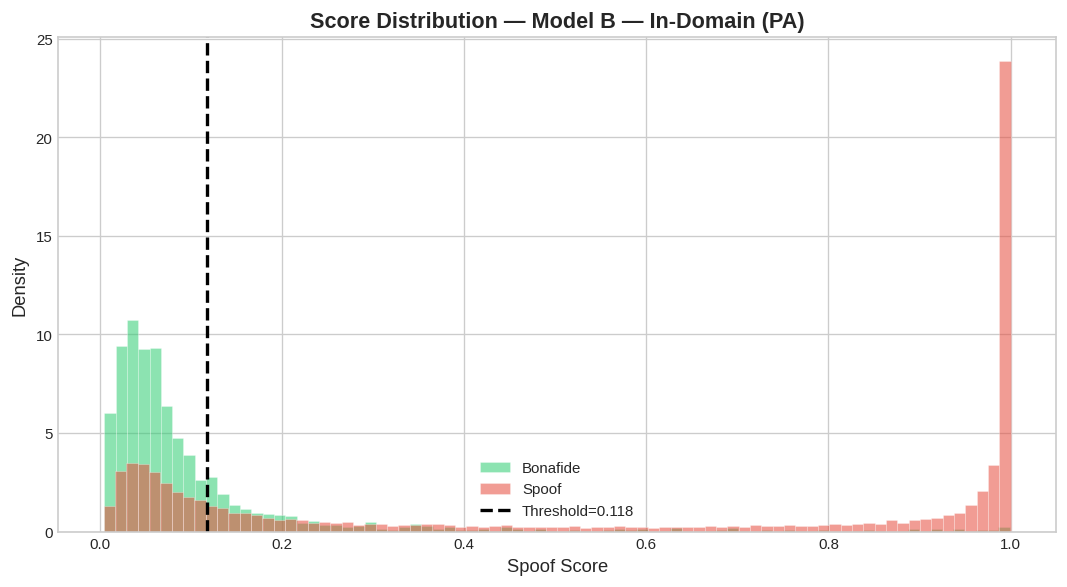

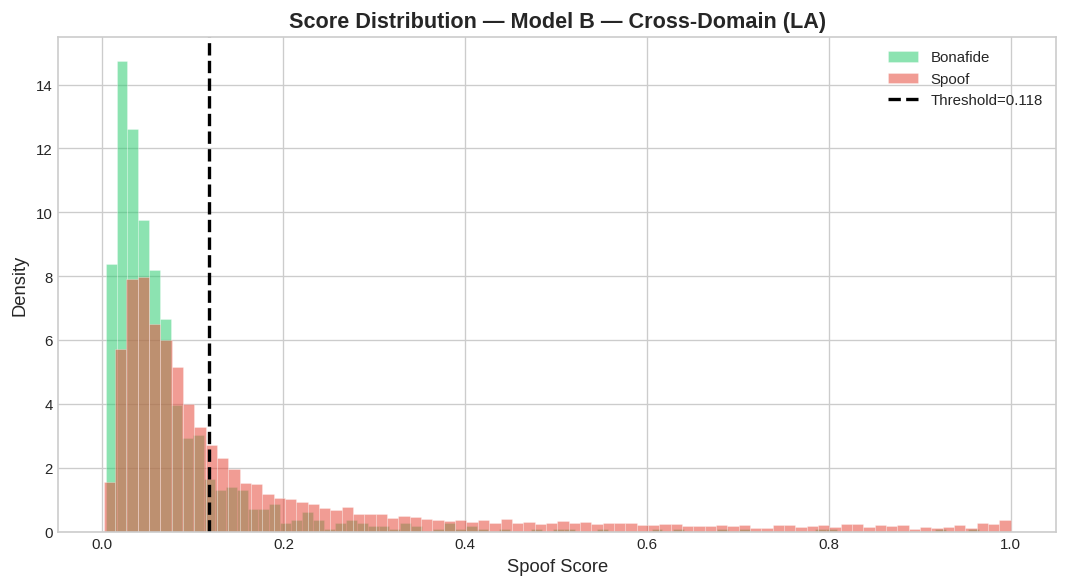

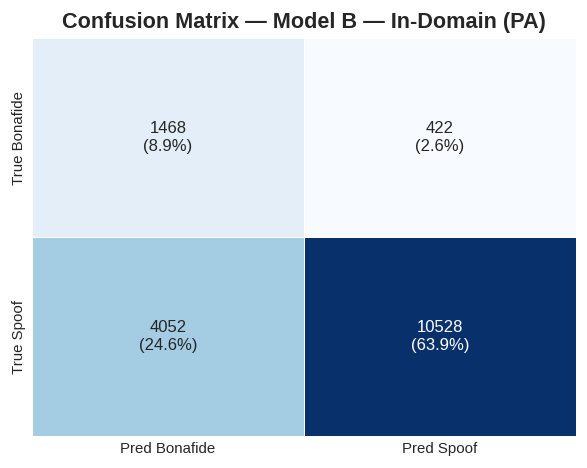

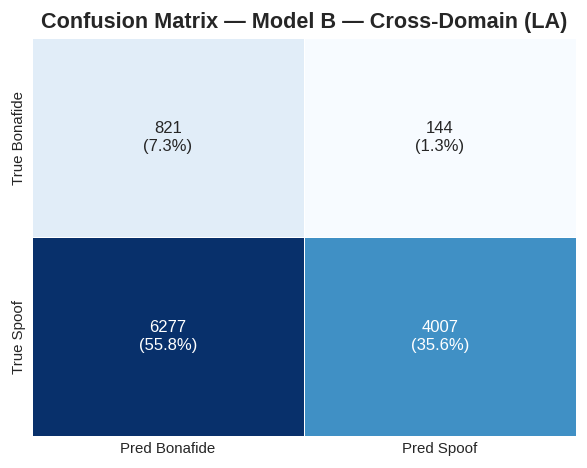

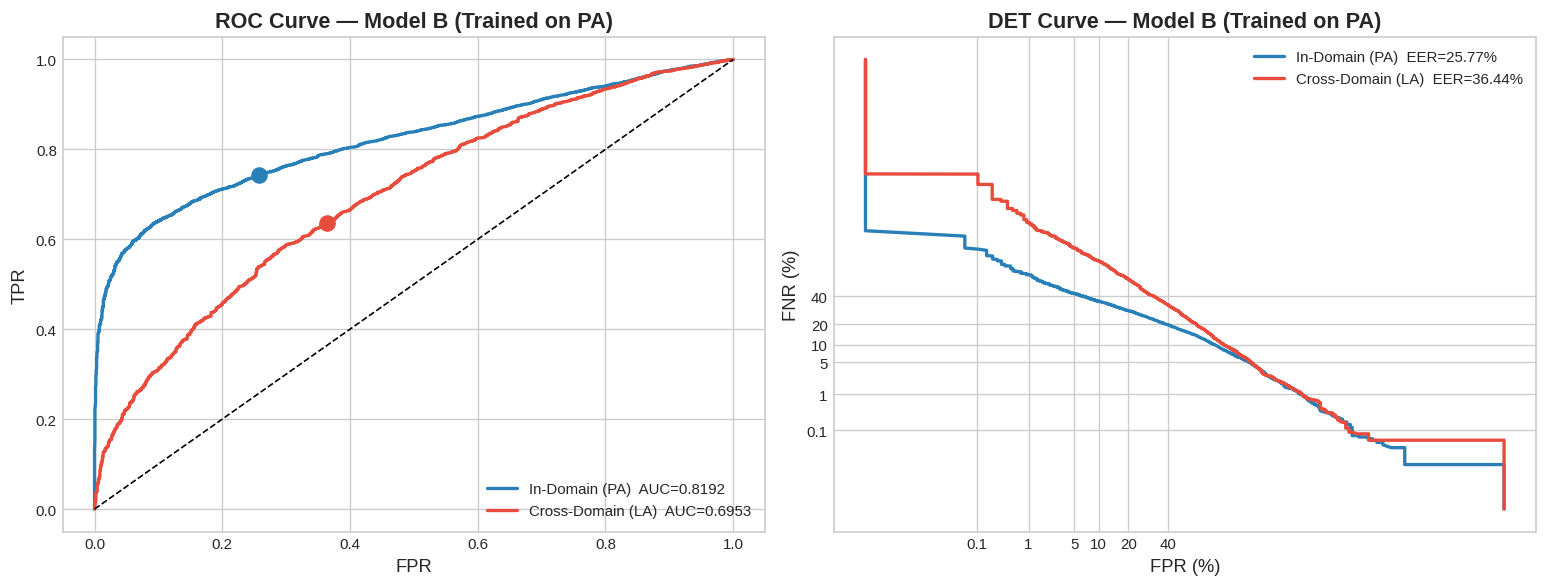

In [22]:
plot_score_distribution(y_PA_in,  s_PA_in,  threshold_PA, "Model B — In-Domain (PA)",    "modelB_in")
plot_score_distribution(y_PA_out, s_PA_out, threshold_PA, "Model B — Cross-Domain (LA)", "modelB_out")
plot_confusion_matrix(metrics_PA_in,  "Model B — In-Domain (PA)",    "modelB_cm_in")
plot_confusion_matrix(metrics_PA_out, "Model B — Cross-Domain (LA)", "modelB_cm_out")
plot_roc_and_det(
    {"In-Domain (PA)": metrics_PA_in, "Cross-Domain (LA)": metrics_PA_out},
    "Model B (Trained on PA)", "modelB")

## **15. Final Cross-Model Comparison**

All four scenarios compared on EER, ACER, AUC-ROC and Accuracy.

In [23]:
# ── Master summary table ──────────────────────────────────────────────────────
def _ensure_metrics(model_name, train_name, in_domain_loaders, out_domain_loaders):
    metrics_in_name = f"metrics_{train_name}_in"
    metrics_out_name = f"metrics_{train_name}_out"

    if metrics_in_name in globals() and metrics_out_name in globals():
        return globals()[metrics_in_name], globals()[metrics_out_name]

    model_var = f"model_{train_name}"
    threshold_var = f"threshold_{train_name}"
    ckpt_path = Path(CFG.model_dir) / f"{model_name}_best.pt"

    if model_var not in globals():
        globals()[model_var] = AASIST(CFG).to(DEVICE)
    if ckpt_path.exists():
        globals()[model_var].load_state_dict(torch.load(ckpt_path, map_location=DEVICE))

    if threshold_var not in globals():
        if "val" in in_domain_loaders:
            _, _, y_val, s_val = run_epoch(globals()[model_var], in_domain_loaders["val"], crit_eval, None, DEVICE, eval_scaler, False)
            _, globals()[threshold_var] = compute_eer(y_val, s_val)
        else:
            globals()[threshold_var] = 0.5

    _, _, y_in, s_in = run_epoch(globals()[model_var], in_domain_loaders["test"], crit_eval, None, DEVICE, eval_scaler, False)
    _, _, y_out, s_out = run_epoch(globals()[model_var], out_domain_loaders["test"], crit_eval, None, DEVICE, eval_scaler, False)

    globals()[metrics_in_name] = compute_all_metrics(y_in, s_in, globals()[threshold_var])
    globals()[metrics_out_name] = compute_all_metrics(y_out, s_out, globals()[threshold_var])
    return globals()[metrics_in_name], globals()[metrics_out_name]

metrics_LA_in, metrics_LA_out = _ensure_metrics("ModelA_LA", "LA", loaders_LA, loaders_PA)
metrics_PA_in, metrics_PA_out = _ensure_metrics("ModelB_PA", "PA", loaders_PA, loaders_LA)

t = PrettyTable()
t.title = "Full Experimental Summary — AASIST LA vs PA"
t.field_names = ["Model","Train","Test","EER (%)","ACER (%)","AUC-ROC","Accuracy"]
t.align = "r"
for c in ["Model","Train","Test"]: t.align[c] = "l"

scenarios = [
    ("Model A","LA","LA — in-domain",    metrics_LA_in),
    ("Model A","LA","PA — cross-domain", metrics_LA_out),
    ("Model B","PA","PA — in-domain",    metrics_PA_in),
    ("Model B","PA","LA — cross-domain", metrics_PA_out),
]
for mn, tr, te, m in scenarios:
    t.add_row([mn, tr, te,
               f"{m['eer']*100:.2f}", f"{m['acer']*100:.2f}",
               f"{m['auc_roc']:.4f}", f"{m['accuracy']*100:.2f}%"])
print(t)

+-------------------------------------------------------------------------------+
|                  Full Experimental Summary — AASIST LA vs PA                  |
+---------+-------+-------------------+---------+----------+---------+----------+
| Model   | Train | Test              | EER (%) | ACER (%) | AUC-ROC | Accuracy |
+---------+-------+-------------------+---------+----------+---------+----------+
| Model A | LA    | LA — in-domain    |   10.16 |    12.21 |  0.9567 |   79.56% |
| Model A | LA    | PA — cross-domain |   27.05 |    27.89 |  0.8025 |   56.77% |
| Model B | PA    | PA — in-domain    |   25.77 |    25.06 |  0.8192 |   72.84% |
| Model B | PA    | LA — cross-domain |   36.44 |    37.98 |  0.6953 |   42.92% |
+---------+-------+-------------------+---------+----------+---------+----------+


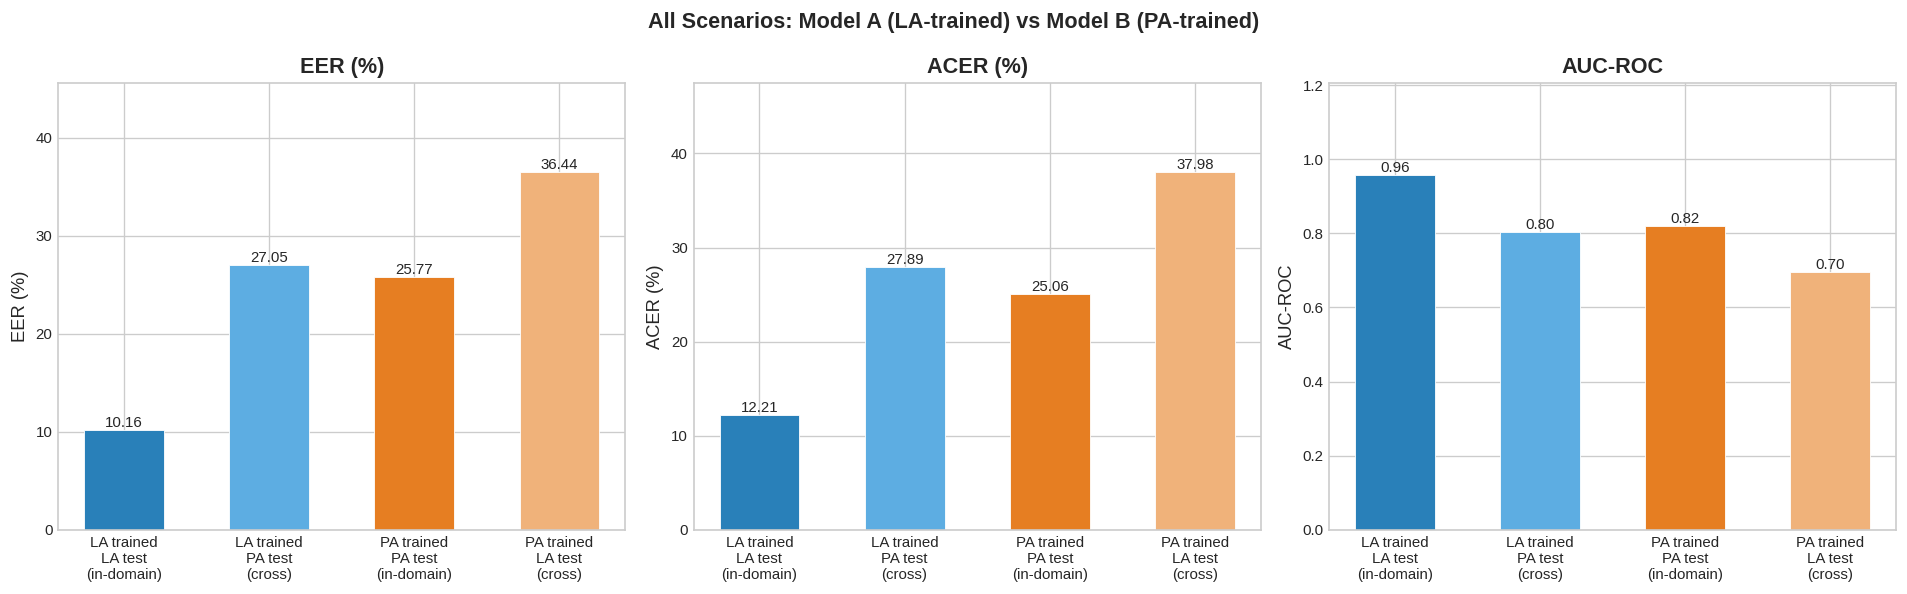

In [24]:
# ── Grouped bar chart ─────────────────────────────────────────────────────────
# Ensure metrics exist before plotting
if "metrics_LA_in" not in globals() or "metrics_LA_out" not in globals() or "metrics_PA_in" not in globals() or "metrics_PA_out" not in globals():
    metrics_LA_in, metrics_LA_out = _ensure_metrics("ModelA_LA", "LA", loaders_LA, loaders_PA)
    metrics_PA_in, metrics_PA_out = _ensure_metrics("ModelB_PA", "PA", loaders_PA, loaders_LA)

labels_bar = ["LA trained\nLA test\n(in-domain)", "LA trained\nPA test\n(cross)",
               "PA trained\nPA test\n(in-domain)", "PA trained\nLA test\n(cross)"]
metrics_list = [metrics_LA_in, metrics_LA_out, metrics_PA_in, metrics_PA_out]
bar_colors   = ["#2980b9","#5dade2","#e67e22","#f0b27a"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, key, ylabel in zip(axes,
    ["eer","acer","auc_roc"],
    ["EER (%)","ACER (%)","AUC-ROC"]):
    vals = [m[key]*(100 if key!="auc_roc" else 1) for m in metrics_list]
    bars = ax.bar(labels_bar, vals, color=bar_colors, edgecolor="white", lw=0.5, width=0.55)
    ax.bar_label(bars, fmt="%.2f", label_type="edge", fontsize=9)
    ax.set_title(ylabel, fontweight="bold"); ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(vals)*1.25+0.01)
plt.suptitle("All Scenarios: Model A (LA-trained) vs Model B (PA-trained)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CFG.plot_dir}/final_comparison_bars.png", dpi=150, bbox_inches="tight")
plt.show()

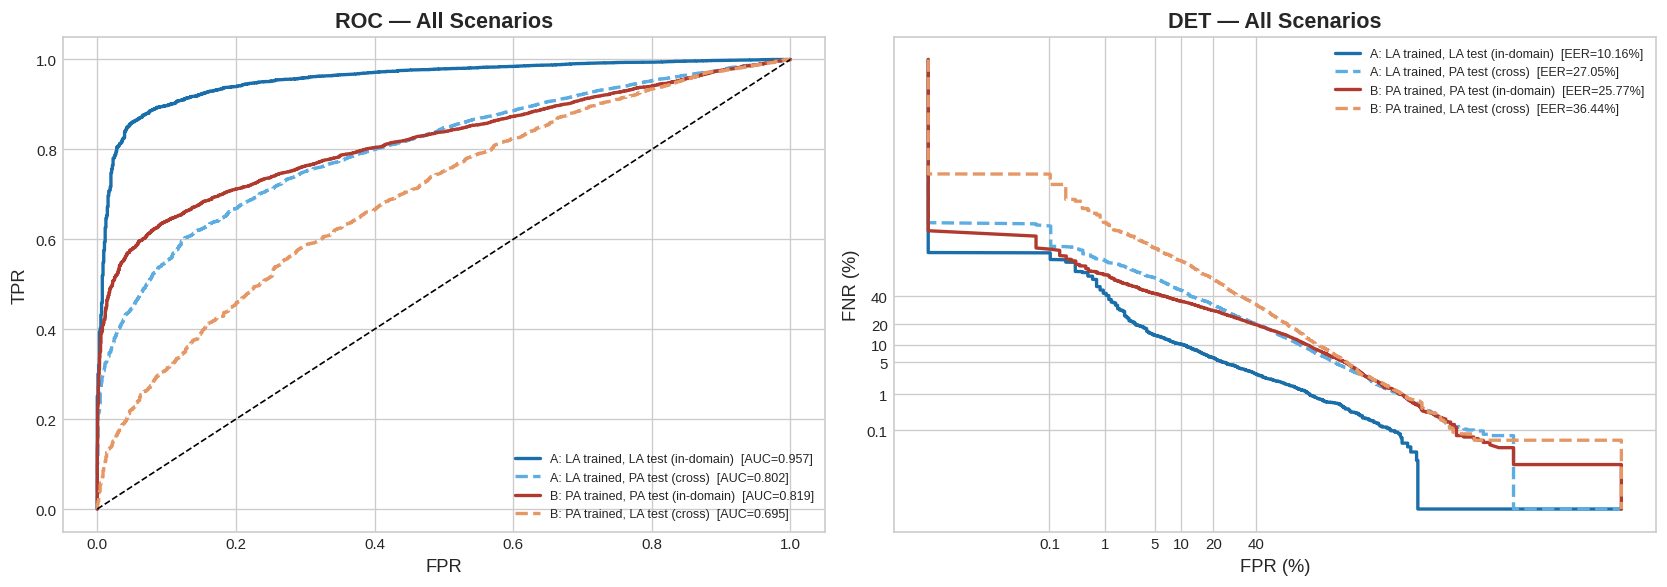


All experiments complete. Plots saved to: plots


In [25]:
# ── Combined 4-curve ROC + DET ────────────────────────────────────────────────
# Ensure metrics exist before plotting
if "metrics_LA_in" not in globals() or "metrics_LA_out" not in globals() or "metrics_PA_in" not in globals() or "metrics_PA_out" not in globals():
    metrics_LA_in, metrics_LA_out = _ensure_metrics("ModelA_LA", "LA", loaders_LA, loaders_PA)
    metrics_PA_in, metrics_PA_out = _ensure_metrics("ModelB_PA", "PA", loaders_PA, loaders_LA)

all_curves = {
    "A: LA trained, LA test (in-domain)"  : (metrics_LA_in,  "#1a6fab", "-"),
    "A: LA trained, PA test (cross)"      : (metrics_LA_out, "#5dade2", "--"),
    "B: PA trained, PA test (in-domain)"  : (metrics_PA_in,  "#b03a2e", "-"),
    "B: PA trained, LA test (cross)"      : (metrics_PA_out, "#e59866", "--"),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
eps = 1e-6
for lbl, (m, color, ls) in all_curves.items():
    axes[0].plot(m["fpr_arr"], m["tpr_arr"],
                 label=f"{lbl}  [AUC={m['auc_roc']:.3f}]", color=color, lw=2, ls=ls)
    fpr_nd = scipy_norm.ppf(np.clip(m["fpr_arr"], eps, 1-eps))
    fnr_nd = scipy_norm.ppf(np.clip(1-m["tpr_arr"], eps, 1-eps))
    valid  = np.isfinite(fpr_nd) & np.isfinite(fnr_nd)
    axes[1].plot(fpr_nd[valid], fnr_nd[valid],
                 label=f"{lbl}  [EER={m['eer']*100:.2f}%]", color=color, lw=2, ls=ls)

axes[0].plot([0,1],[0,1],"k--",lw=1)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("ROC — All Scenarios", fontweight="bold")
axes[0].legend(fontsize=7.5, loc="lower right")

ticks = [0.1,1,5,10,20,40]; tloc = scipy_norm.ppf([t/100 for t in ticks])
axes[1].set_xticks(tloc); axes[1].set_xticklabels(ticks)
axes[1].set_yticks(tloc); axes[1].set_yticklabels(ticks)
axes[1].set_xlabel("FPR (%)"); axes[1].set_ylabel("FNR (%)")
axes[1].set_title("DET — All Scenarios", fontweight="bold")
axes[1].legend(fontsize=7.5)
plt.tight_layout()
plt.savefig(f"{CFG.plot_dir}/final_roc_det_all.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nAll experiments complete. Plots saved to:", CFG.plot_dir)

## **16. Architecture Details (Model A & Model B)**

This section prints structured architecture details including layers, activations, and attention blocks for both trained models.

In [29]:
def describe_aasist_architecture(model: nn.Module, model_name: str):
    print(f"\n{'='*88}")
    print(f"{model_name} - AASIST Architecture Details")
    print(f"{'='*88}")

    print("\n1) Front-end")
    print("   - SincConv:")
    print(f"     out_channels={model.sinc.out_channels}, kernel_size={model.sinc.kernel_size}, sample_rate={model.sinc.sample_rate}")
    print("   - BatchNorm1d(70)")
    print("   - MaxPool1d(kernel_size=3)")
    print("   - Dropout(p=0.05)")
    print("   - Activation: LeakyReLU(negative_slope=0.3)")

    print("\n2) Residual Encoder")
    for i, blk in enumerate(model.enc_blocks, start=1):
        print(f"   - ResBlock {i}: conv1 {blk.conv1.in_channels}->{blk.conv1.out_channels}, conv2 {blk.conv2.in_channels}->{blk.conv2.out_channels}")
        print("     BatchNorm + LeakyReLU(0.3) + residual skip + MaxPool1d(3)")
    print(f"   - Final ResBlock: conv1 {model.block_last.conv1.in_channels}->{model.block_last.conv1.out_channels}, conv2 {model.block_last.conv2.in_channels}->{model.block_last.conv2.out_channels}")
    print("     BatchNorm + LeakyReLU(0.3) + Dropout(p=0.05)")

    print("\n3) Attention and Graph Module")
    print("   - HSGAL (Heterogeneous Stacked Graph Attention Layer)")
    print(f"   - GAT source dims: in={model.hsgal.gat_s.proj.in_features}, out={model.hsgal.gat_s.proj.out_features}, K={model.hsgal.gat_s.K}")
    print(f"   - GAT target dims: in={model.hsgal.gat_t.proj.in_features}, out={model.hsgal.gat_t.proj.out_features}, K={model.hsgal.gat_t.K}")
    print("   - GraphAttention activation: LeakyReLU(0.2) and ELU")
    print(f"   - Cross-attention projection: {model.hsgal.cross.in_features}->{model.hsgal.cross.out_features}")
    print(f"   - Attention temperature: {model.hsgal.temp}")

    print("\n4) Classification Head")
    print(f"   - FC1: {model.fc1.in_features}->{model.fc1.out_features}")
    print(f"   - BatchNorm1d({model.bn_fc.num_features})")
    print("   - Activation: LeakyReLU(0.3)")
    print(f"   - FC2: {model.fc2.in_features}->{model.fc2.out_features} (2-class logits)")

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print("\n5) Parameter Count")
    print(f"   - Total params: {total_params:,}")
    print(f"   - Trainable params: {trainable_params:,}")


if "model_LA" not in globals():
    model_LA = AASIST(CFG).to(DEVICE)
if "model_PA" not in globals():
    model_PA = AASIST(CFG).to(DEVICE)

describe_aasist_architecture(model_LA, "Model A")
describe_aasist_architecture(model_PA, "Model B")


Model A - AASIST Architecture Details

1) Front-end
   - SincConv:
     out_channels=70, kernel_size=1025, sample_rate=16000
   - BatchNorm1d(70)
   - MaxPool1d(kernel_size=3)
   - Dropout(p=0.05)
   - Activation: LeakyReLU(negative_slope=0.3)

2) Residual Encoder
   - ResBlock 1: conv1 70->32, conv2 32->32
     BatchNorm + LeakyReLU(0.3) + residual skip + MaxPool1d(3)
   - ResBlock 2: conv1 32->32, conv2 32->32
     BatchNorm + LeakyReLU(0.3) + residual skip + MaxPool1d(3)
   - ResBlock 3: conv1 32->64, conv2 64->64
     BatchNorm + LeakyReLU(0.3) + residual skip + MaxPool1d(3)
   - ResBlock 4: conv1 64->64, conv2 64->64
     BatchNorm + LeakyReLU(0.3) + residual skip + MaxPool1d(3)
   - Final ResBlock: conv1 64->64, conv2 64->64
     BatchNorm + LeakyReLU(0.3) + Dropout(p=0.05)

3) Attention and Graph Module
   - HSGAL (Heterogeneous Stacked Graph Attention Layer)
   - GAT source dims: in=64, out=64, K=4
   - GAT target dims: in=64, out=64, K=4
   - GraphAttention activation: LeakyR

In [30]:
# Training hyperparameters summary (shared setup for Model A and Model B)
def print_training_hyperparameters(cfg: Config):
    tbl = PrettyTable()
    tbl.title = "Training Hyperparameters"
    tbl.field_names = ["Parameter", "Value"]
    tbl.align = "l"

    scheduler_desc = cfg.scheduler
    if cfg.scheduler == "cosine":
        scheduler_desc = f"CosineAnnealingLR(T_max={cfg.num_epochs}, eta_min={cfg.lr_min})"
    elif cfg.scheduler == "step":
        scheduler_desc = f"StepLR(step_size={cfg.step_size}, gamma={cfg.gamma})"
    else:
        scheduler_desc = f"ReduceLROnPlateau(factor=0.5, patience=5, min_lr={cfg.lr_min})"

    rows = [
        ("Optimizer", "Adam"),
        ("Initial learning rate", f"{cfg.lr}"),
        ("Weight decay", f"{cfg.weight_decay}"),
        ("Scheduler", scheduler_desc),
        ("Batch size", f"{cfg.batch_size}"),
        ("Epochs (max)", f"{cfg.num_epochs}"),
        ("Early stopping", f"patience={cfg.early_stopping_patience}, min_delta=1e-4 (monitor: val EER)"),
        ("Loss function", "Weighted CrossEntropyLoss"),
        ("Gradient clipping", f"max_norm={cfg.grad_clip}"),
        ("Automatic mixed precision", f"enabled={DEVICE.type == 'cuda'}"),
        ("Workers", f"{cfg.num_workers}"),
        ("Input length (samples)", f"{cfg.n_samples}"),
        ("Sample rate", f"{cfg.sample_rate} Hz"),
        ("Seed", f"{cfg.seed}"),
    ]

    for k, v in rows:
        tbl.add_row([k, v])

    print(tbl)


print_training_hyperparameters(CFG)

+---------------------------------------------------------------------------+
|                          Training Hyperparameters                         |
+---------------------------+-----------------------------------------------+
| Parameter                 | Value                                         |
+---------------------------+-----------------------------------------------+
| Optimizer                 | Adam                                          |
| Initial learning rate     | 0.0001                                        |
| Weight decay              | 0.0001                                        |
| Scheduler                 | CosineAnnealingLR(T_max=20, eta_min=1e-06)    |
| Batch size                | 64                                            |
| Epochs (max)              | 20                                            |
| Early stopping            | patience=6, min_delta=1e-4 (monitor: val EER) |
| Loss function             | Weighted CrossEntropyLoss         

In [32]:
# Model footprint + detailed classification metrics

def _ensure_models_loaded():
    if "model_LA" not in globals():
        globals()["model_LA"] = AASIST(CFG).to(DEVICE)
    if "model_PA" not in globals():
        globals()["model_PA"] = AASIST(CFG).to(DEVICE)

    ckpt_a = Path(CFG.model_dir) / "ModelA_LA_best.pt"
    ckpt_b = Path(CFG.model_dir) / "ModelB_PA_best.pt"

    if ckpt_a.exists():
        globals()["model_LA"].load_state_dict(torch.load(ckpt_a, map_location=DEVICE))
    if ckpt_b.exists():
        globals()["model_PA"].load_state_dict(torch.load(ckpt_b, map_location=DEVICE))


def _param_counts(model: nn.Module):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


def _ckpt_size_mb(path: Path) -> float:
    return (path.stat().st_size / (1024 ** 2)) if path.exists() else float("nan")


def _print_model_footprint():
    _ensure_models_loaded()

    ckpt_a = Path(CFG.model_dir) / "ModelA_LA_best.pt"
    ckpt_b = Path(CFG.model_dir) / "ModelB_PA_best.pt"

    total_a, trainable_a = _param_counts(model_LA)
    total_b, trainable_b = _param_counts(model_PA)

    t = PrettyTable()
    t.title = "Model Parameters and Saved-Weights Size"
    t.field_names = ["Model", "Trainable Params", "Total Params", "Weights Size (MB)"]
    t.align = "r"
    t.align["Model"] = "l"
    t.add_row([
        "Model A",
        f"{trainable_a:,}",
        f"{total_a:,}",
        f"{_ckpt_size_mb(ckpt_a):.2f}" if ckpt_a.exists() else "N/A",
    ])
    t.add_row([
        "Model B",
        f"{trainable_b:,}",
        f"{total_b:,}",
        f"{_ckpt_size_mb(ckpt_b):.2f}" if ckpt_b.exists() else "N/A",
    ])
    print(t)


def _print_metrics_block(model_name: str, condition_name: str, m: dict):
    t = PrettyTable()
    t.title = f"{model_name} - {condition_name}"
    t.field_names = [
        "Confusion [TN, FP, FN, TP]",
        "Precision (Bonafide/Spoof)",
        "Recall (Bonafide/Spoof)",
        "F1 (Bonafide/Spoof)",
    ]
    t.add_row([
        f"[{m['TN']}, {m['FP']}, {m['FN']}, {m['TP']}]",
        f"{m['precision_bonafide']:.4f} / {m['precision_spoof']:.4f}",
        f"{m['recall_bonafide']:.4f} / {m['recall_spoof']:.4f}",
        f"{m['f1_bonafide']:.4f} / {m['f1_spoof']:.4f}",
    ])
    print(t)


# Ensure metrics are available
if "metrics_LA_in" not in globals() or "metrics_LA_out" not in globals() or "metrics_PA_in" not in globals() or "metrics_PA_out" not in globals():
    metrics_LA_in, metrics_LA_out = _ensure_metrics("ModelA_LA", "LA", loaders_LA, loaders_PA)
    metrics_PA_in, metrics_PA_out = _ensure_metrics("ModelB_PA", "PA", loaders_PA, loaders_LA)

_print_model_footprint()
_print_metrics_block("Model A", "In-Domain", metrics_LA_in)
_print_metrics_block("Model A", "Cross-Domain", metrics_LA_out)
_print_metrics_block("Model B", "In-Domain", metrics_PA_in)
_print_metrics_block("Model B", "Cross-Domain", metrics_PA_out)

+---------------------------------------------------------------+
|            Model Parameters and Saved-Weights Size            |
+---------+------------------+--------------+-------------------+
| Model   | Trainable Params | Total Params | Weights Size (MB) |
+---------+------------------+--------------+-------------------+
| Model A |          104,666 |      104,666 |              0.44 |
| Model B |          104,666 |      104,666 |              0.44 |
+---------+------------------+--------------+-------------------+
+---------------------------------------------------------------------------------------------------------+
|                                           Model A - In-Domain                                           |
+----------------------------+----------------------------+-------------------------+---------------------+
| Confusion [TN, FP, FN, TP] | Precision (Bonafide/Spoof) | Recall (Bonafide/Spoof) | F1 (Bonafide/Spoof) |
+----------------------------+----------

In [33]:
# Final benchmark: computation profile on a standardized 5-second sample
import time
import platform
from pathlib import Path

import numpy as np
import torch
from thop import profile


def _get_cpu_model_name() -> str:
    try:
        with open("/proc/cpuinfo", "r", encoding="utf-8") as f:
            for line in f:
                if line.lower().startswith("model name"):
                    return line.split(":", 1)[1].strip()
    except Exception:
        pass
    return platform.processor() or "Unknown CPU"


def _get_gpu_model_name() -> str:
    if torch.cuda.is_available():
        return torch.cuda.get_device_name(0)
    return "No GPU detected"


def _ensure_5s_clip(sr: int = 16000) -> torch.Tensor:
    target_len = 5 * sr
    cache_dir = Path(CFG.cache_dir)
    candidates = sorted(cache_dir.glob("*.pt"))

    if candidates:
        raw = torch.load(candidates[0], weights_only=True)
        if isinstance(raw, torch.Tensor):
            wave = raw.detach().cpu().numpy().astype(np.float32)
        else:
            wave = np.asarray(raw, dtype=np.float32)
    else:
        wave = np.random.randn(target_len).astype(np.float32) * 0.01

    if len(wave) >= target_len:
        wave = wave[:target_len]
    else:
        wave = np.tile(wave, target_len // max(1, len(wave)) + 1)[:target_len]

    x = torch.from_numpy(wave).float().unsqueeze(0).unsqueeze(0)
    return x.to(DEVICE)


def _mean_latency_ms(model: torch.nn.Module, x: torch.Tensor, iters: int = 100, warmup: int = 10) -> float:
    model.eval()
    with torch.no_grad():
        for _ in range(warmup):
            _ = model(x)

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
            start_event = torch.cuda.Event(enable_timing=True)
            end_event = torch.cuda.Event(enable_timing=True)
            times = []
            for _ in range(iters):
                start_event.record()
                _ = model(x)
                end_event.record()
                torch.cuda.synchronize()
                times.append(start_event.elapsed_time(end_event))
            return float(np.mean(times))

        t0 = time.perf_counter()
        for _ in range(iters):
            _ = model(x)
        t1 = time.perf_counter()
        return float((t1 - t0) * 1000.0 / iters)


def _param_count(model: torch.nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Ensure models exist and weights are loaded
if "model_LA" not in globals():
    model_LA = AASIST(CFG).to(DEVICE)
if "model_PA" not in globals():
    model_PA = AASIST(CFG).to(DEVICE)

ckpt_a = Path(CFG.model_dir) / "ModelA_LA_best.pt"
ckpt_b = Path(CFG.model_dir) / "ModelB_PA_best.pt"
if ckpt_a.exists():
    model_LA.load_state_dict(torch.load(ckpt_a, map_location=DEVICE))
if ckpt_b.exists():
    model_PA.load_state_dict(torch.load(ckpt_b, map_location=DEVICE))

x5 = _ensure_5s_clip(sr=CFG.sample_rate)

# Computational cost (MACs/FLOPs)
macs_a, params_a_thop = profile(model_LA, inputs=(x5,), verbose=False)
macs_b, params_b_thop = profile(model_PA, inputs=(x5,), verbose=False)
flops_a = 2.0 * macs_a
flops_b = 2.0 * macs_b

# Inference latency over 100 independent iterations
lat_a = _mean_latency_ms(model_LA, x5, iters=100, warmup=10)
lat_b = _mean_latency_ms(model_PA, x5, iters=100, warmup=10)

cpu_name = _get_cpu_model_name()
gpu_name = _get_gpu_model_name()

print(f"Input duration benchmarked: 5.0 seconds @ {CFG.sample_rate} Hz")
print(f"CPU: {cpu_name}")
print(f"GPU: {gpu_name}")

tbl = PrettyTable()
tbl.title = "Benchmarking and Computation Profile (5-second input)"
tbl.field_names = [
    "Model",
    "Trainable Params",
    "MACs",
    "FLOPs (approx)",
    "Mean Latency (ms, 100 iters)",
]
tbl.align = "r"
tbl.align["Model"] = "l"

fmt = lambda v: f"{v/1e6:.3f} M"

# Use explicit trainable param count from model; THOP param count shown for cross-check in comments only.
params_a = _param_count(model_LA)
params_b = _param_count(model_PA)

_ = (params_a_thop, params_b_thop)

tbl.add_row(["Model A", f"{params_a:,}", fmt(macs_a), fmt(flops_a), f"{lat_a:.3f}"])
tbl.add_row(["Model B", f"{params_b:,}", fmt(macs_b), fmt(flops_b), f"{lat_b:.3f}"])
print(tbl)

Input duration benchmarked: 5.0 seconds @ 16000 Hz
CPU: AMD EPYC 7313 16-Core Processor
GPU: NVIDIA RTX A5000
+----------------------------------------------------------------------------------------+
|                 Benchmarking and Computation Profile (5-second input)                  |
+---------+------------------+-----------+----------------+------------------------------+
| Model   | Trainable Params |      MACs | FLOPs (approx) | Mean Latency (ms, 100 iters) |
+---------+------------------+-----------+----------------+------------------------------+
| Model A |          104,666 | 530.202 M |     1060.404 M |                        3.882 |
| Model B |          104,666 | 530.202 M |     1060.404 M |                        3.853 |
+---------+------------------+-----------+----------------+------------------------------+
